In [ ]:
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchmetrics.regression import R2Score
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
import xarray as xr
from data_utils import load_DYAMOND_data, load_grid, load_ds
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
# Set device to gpu if avaible, else to cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Compare precipitation histograms

In [2]:
# Load predicitions
def get_precip(path, precip_ind=8, rescale_precip=True, epsilon=None):
    data = np.load(path)
    coord = data[:, 0, 0].astype(int)
    precip = data[:, :, precip_ind]
    precip_pred = data[:, :, precip_ind + 1]

    if rescale_precip:
        precip_pred = np.exp(precip_pred) - epsilon
        precip = np.exp(precip) - epsilon
    precip[precip < 0] = 0.0
    precip_pred[precip_pred < 0] = 0.0
    return precip, precip_pred, coord

In [3]:
def precip_hist(precip_flatt, bins, density, alpha, label, color=None):
    precip_flatt = precip_flatt[precip_flatt > 0.0]
    precip_hist, bins = np.histogram(precip_flatt, density=density, bins=bins)
    plt.plot(bins[1:], precip_hist, alpha=alpha, label=label, color=color, linewidth=2)
    return precip_hist, bins

In [4]:
def precip_plot(path_base, path_org, path_org_ED, path_org_nonlinED, spinup=20, past_timesteps=20, save=False,
                file_name='DYAMOND_R2.png'):
    # Load baseline
    precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
    precip = precip[:, past_timesteps + 1 + spinup:]
    precip_base_pred = precip_base_pred[:, past_timesteps + 1 + spinup:]

    # Load autoencoder
    _, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
    precip_org_pred = precip_org_pred[:, 1 + spinup:]

    # Load linear ODE
    precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)
    precip_org_ED_pred = precip_org_ED_pred[:, spinup:]
    precip_org_ED_True = precip_org_ED_True[:, spinup:]

    # Plot params
    rotation, FS, xlim, width, bp = -20, 14, 30, '40%', 1.2

    if path_org_nonlinED:
        # Load nonlinear ODE
        precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)
        precip_org_nonlinED_pred = precip_org_nonlinED_pred[:, spinup:]
        precip_org_nonlinED_True = precip_org_nonlinED_True[:, spinup:]
        rotation, FS, xlim, width, bp = -30, 13, 40, '55%', .7

    # =========================
    # Compute R²
    # =========================
    R2_base = round(R2Score()(torch.tensor(precip_base_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
    R2_org = round(R2Score()(torch.tensor(precip_org_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
    R2_org_ed = round(R2Score()(torch.tensor(precip_org_ED_pred.flatten()), torch.tensor(precip_org_ED_True.flatten())).item(), 2)

    # =========================
    # Main plot
    # =========================
    fig, ax = plt.subplots(figsize=(5, 4))
    density = False

    # Ground truth
    _, bins = precip_hist(precip.flatten(), bins=120, alpha=1.0, color='black', density=density, label='DYAMOND')

    # Models
    precip_hist(precip_base_pred.flatten(),bins=bins,alpha=1.0,color='tab:blue',density=density,label=None)
    precip_hist(precip_org_pred.flatten(),bins=bins,alpha=1.0,color='tab:purple',density=density,label=None)
    precip_hist(precip_org_ED_pred.flatten(),bins=bins,alpha=1.0,color='tab:orange',density=density,label=None)
    if path_org_nonlinED:
        R2_org_nonlined = round(R2Score()(torch.tensor(precip_org_nonlinED_pred.flatten()), torch.tensor(precip_org_nonlinED_True.flatten())).item(), 2)
        precip_hist(precip_org_nonlinED_pred.flatten(), bins=bins, alpha=1.0, color='tab:brown', density=density, label=None)
    else:
        ax.text(.05, .95, 'a)', ha='left', va='top', fontweight='bold', fontsize=FS, transform=ax.transAxes)

    # Axes styling
    ax.set_yscale('log')
    ax.set_xlim(0, xlim)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Precipitation [mm/h]', fontsize=FS)
    ax.set_ylabel('Frequency', fontsize=FS)
    ax.tick_params(axis='both', labelsize=FS)
    ax.legend(loc='lower left', fontsize=FS)

    # =========================
    # Inset: R² bar plot
    # =========================
    axins = inset_axes(ax, width=width, height="40%", loc='upper right', borderpad=bp)
    r2_values = [R2_org, R2_org_ed, R2_base]
    colors = ['tab:purple', 'tab:orange', 'tab:blue']
    labels = ['autoencoder','linear ODE','baseline']
    if path_org_nonlinED:
        r2_values.insert(2, R2_org_nonlined)
        colors.insert(2, 'tab:brown')
        labels.insert(2, 'nonlinear ODE')
    bars = axins.bar(range(len(r2_values)), r2_values, color=colors, width=0.6)

    # Annotate R² values
    for i, v in enumerate(r2_values):
        axins.text(i, v + 0.01, f"{v:.2f}",
                ha='center', va='bottom', fontsize=FS)

    axins.set_xticks(range(len(labels)))
    axins.set_xticklabels(labels, fontsize=FS, rotation=rotation)
    axins.set_ylabel(r'$R^2$', fontsize=FS)
    axins.set_ylim(0, 1)
    axins.tick_params(axis='y', labelsize=FS)

    if save:
        plt.savefig(file_name, dpi=300, bbox_inches='tight')

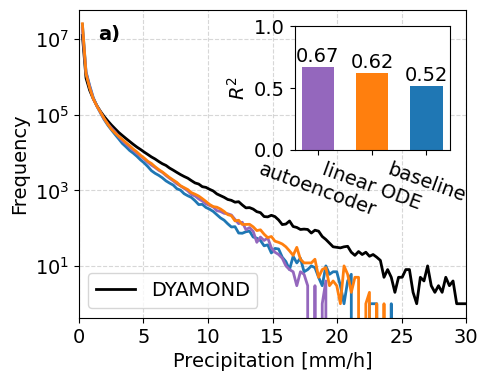

In [12]:
dataset = 'test'
path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
path_org_20 = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
path_org_ED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'

precip_plot(path_base, path_org_20, path_org_ED, path_org_nonlinED=None, save=False, file_name=f'plots_paper/DYAMOND_R2.png')

train


val
test


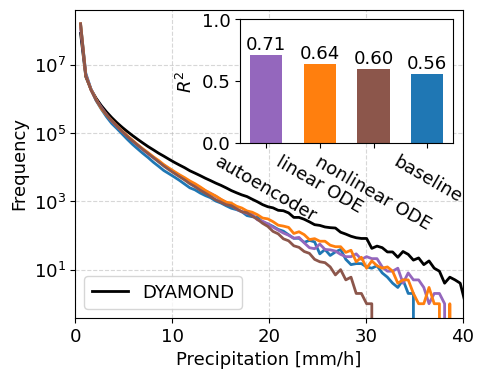

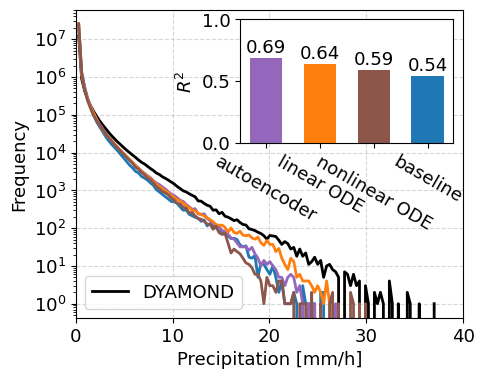

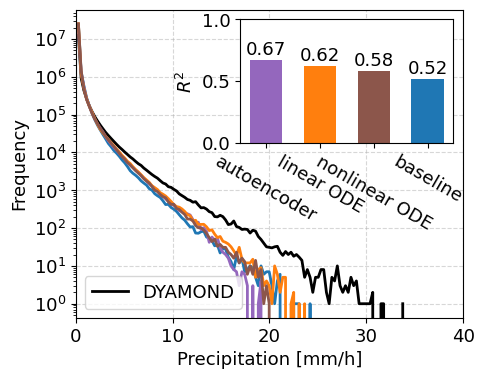

In [5]:
for dataset in ['train', 'val', 'test']:
    print(dataset)
    path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
    path_org_20 = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
    path_org_ED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'

    precip_plot(path_base, path_org_20, path_org_ED, path_org_nonlinED, save=False, file_name=f'plots_paper/DYAMOND_R2_{dataset}.png')

### Spatial MAE

In [6]:
# Load grid
grid_path='/work/bd1179/b309297/schoenfeld26james_PrognosticMemoryParmeterizations/DYAMOND/icon_grid_0019_R02B05_G.nc'
grid = load_grid(grid_path)
lon, lat = grid.clon.values, grid.clat.values

In [7]:
# Load data (global)
path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy'
path_org_20 = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy'
precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
spinup = 20
precip = precip[:, 21 + spinup:]
precip_base_pred = precip_base_pred[:, 21 + spinup:]

_, precip_org_pred, _ = get_precip(path_org_20, rescale_precip=False)
precip_org_pred = precip_org_pred[:, 1 + spinup:]

precip_org_ED_pred, precip_org_ED_True = np.load('precip_ODE_predictions/20260511101043_Pr_combined_test_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
precip_org_ED_pred = precip_org_ED_pred[:, spinup:]
precip_org_ED_True = precip_org_ED_True[:, spinup:]

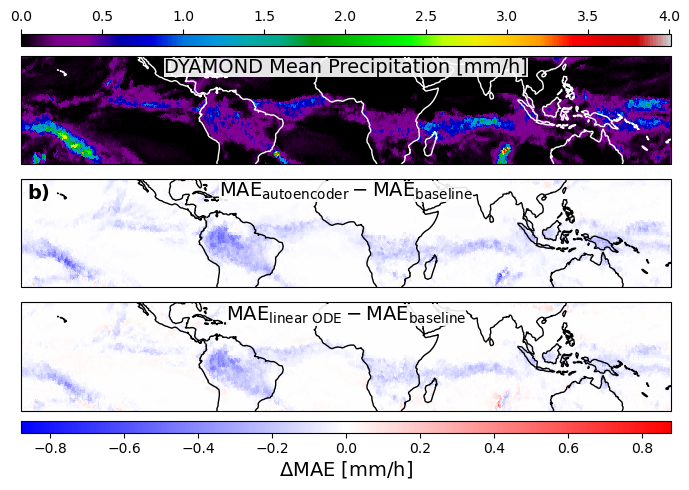

In [ ]:
# =========================
# Settings
# =========================
tropics_min, tropics_max = -30, 30
proj = ccrs.PlateCarree()

# =========================
# Figure + GridSpec (ultra compact)
# =========================
fig = plt.figure(figsize=(7, 5))
FS = 14
gs = GridSpec(
    5, 1,
    figure=fig,
    height_ratios=[0.15, 1.5, 1.5, 1.5, 0.15],
)

# Axes
cax_top = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], projection=proj)
ax2 = fig.add_subplot(gs[2], projection=proj)
ax3 = fig.add_subplot(gs[3], projection=proj)
cax_bottom = fig.add_subplot(gs[4])
ax2.text(0.01, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax2.transAxes)
# =========================
# Panel 1
# =========================
mean_precip = np.mean(precip, axis=1)

sc1 = ax1.tripcolor(
    lon, lat, mean_precip,
    transform=proj,
    cmap="nipy_spectral",
    vmin=0.0,
    vmax=mean_precip.max()
)

# =========================
# MAE fields
# =========================
MAE_org = np.mean(np.abs(precip_org_pred - precip), axis=1)
MAE_base = np.mean(np.abs(precip_base_pred - precip), axis=1)
MAE_ED = np.mean(np.abs(precip_org_ED_pred - precip_org_ED_True), axis=1)

vscale = np.max(np.abs(MAE_org - MAE_base))
cmap_MAE = "bwr"

sc2 = ax2.tripcolor(
    lon, lat, MAE_org - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

sc3 = ax3.tripcolor(
    lon, lat, MAE_ED - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

# =========================
# Shared formatting (tight)
# =========================
labels = [
    "DYAMOND Mean Precipitation [mm/h]",
    r"$\text{MAE}_{\text{autoencoder}} - \text{MAE}_{\text{baseline}}$",
    r"$\text{MAE}_{\text{linear ODE}} - \text{MAE}_{\text{baseline}}$"
]

for ax, label, c in zip([ax1, ax2, ax3], labels, ['white', 'black', 'black']):
    ax.set_extent([lon.min(), lon.max(), tropics_min, tropics_max], crs=proj)
    ax.coastlines(resolution="110m", color=c)

    ax.text(
        0.5, 0.98, label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=FS,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0)
    )

# =========================
# Colorbars (embedded in grid)
# =========================
cb1 = fig.colorbar(sc1, cax=cax_top, orientation="horizontal")
cb1.ax.xaxis.set_ticks_position("top")
#cb1.set_label("DYAMOND Mean Precipitation [mm/h]", fontsize=10)

cb2 = fig.colorbar(sc3, cax=cax_bottom, orientation="horizontal")
cb2.set_label(r"$\Delta$MAE [mm/h]", fontsize=FS, labelpad=2)

# =========================
# Final tightening
# =========================
plt.subplots_adjust(left=0.06, right=0.98, top=0.98, bottom=0.04)
plt.tight_layout()
#plt.savefig('plots_paper/DYAMOND_MAE_global.png', dpi=300, bbox_inches='tight')

### Temporal MAE

In [12]:
def plot_temporal_MAE(precip_pred, precip_true, fig=None, ax=None, plot_kwargs={}, t0=0):
    if not fig:
        fig, ax = plt.subplots()

    mae = np.mean(np.abs(precip_pred - precip_true), axis=0)
    t = np.arange(precip_pred.shape[1]) * 15 / (60*24) + t0
    ax.plot(t, mae, **plot_kwargs)
    ax.set(xlabel='Time [days]', ylabel='Precipitation MAE [mm/h]')

In [9]:
# Load all data for merged plot
# Baseline and autoencoder are stored seperately for train, val, test, so we need to merge them. The ODE predictions are already merged.
precip_org_merged, precip_base_merged, precip = [], [], []
tp = 20 
Ncoords = 81920
spinup = np.empty(shape=(Ncoords, tp))
spinup[:] = np.nan
for dataset in ['train', 'val', 'test']:
    # Load individual datasets
    path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
    path_org = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
    _, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
    precip_true, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
    precip_org_merged.append(spinup)  # add spinup time of autoencoder as NaN values to align with ODE predictions
    precip_org_merged.append(precip_org_pred)
    precip_base_merged.append(precip_base_pred)
    precip.append(precip_true)

dataset = 'merged'
path_org_ED  = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)
precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)
precip_org_merged = np.concatenate(precip_org_merged, axis=1)
precip_base_merged = np.concatenate(precip_base_merged, axis=1)
precip = np.concatenate(precip, axis=1)
precip_org_merged = precip_org_merged[:, 1:]
precip_base_merged = precip_base_merged[:, 1:]
precip = precip[:, 1:]

In [10]:
# Remove Nans from time series for R² computation (only for merged plot, since individual train/val/test plots are already aligned)
mask = ~np.isnan(precip_org_merged.flatten()) 
precip_org_merged_flat = precip_org_merged.flatten()[mask]
precip_flat = precip.flatten()[mask]
R2_org_merged = R2Score()(torch.tensor(precip_org_merged_flat), torch.tensor(precip_flat)).item()
R2_org_merged 

0.6996131402071

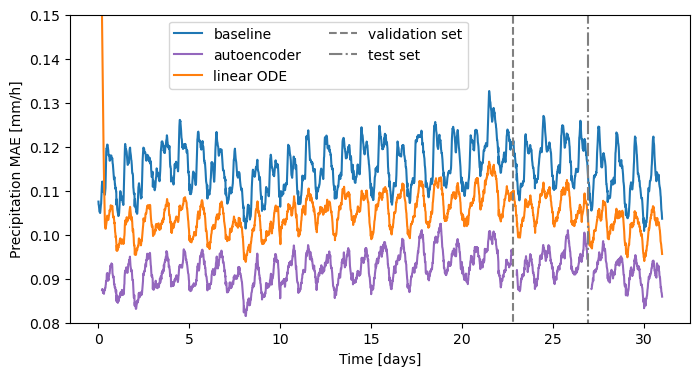

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_temporal_MAE(precip_base_merged, precip, plot_kwargs={'color': 'tab:blue', 'label': 'baseline'}, fig=fig, ax=ax)
plot_temporal_MAE(precip_org_merged, precip, plot_kwargs={'color': 'tab:purple', 'label': 'autoencoder'}, fig=fig, ax=ax)
plot_temporal_MAE(precip_org_ED_pred, precip_org_ED_True, plot_kwargs={'color': 'tab:orange', 'label': 'linear ODE'}, fig=fig, ax=ax)
# plot_temporal_MAE(precip_org_nonlinED_pred, precip_org_nonlinED_True, plot_kwargs={'color': 'tab:brown', 'label': 'nonlinear ODE'}, fig=fig, ax=ax)
ax.set_ylim(0.08, 0.15)
ax.vlines(x=(22.79), ymin=0.05, ymax=0.2, color='grey', linestyle='--', label='validation set')
ax.vlines(x=(26.89), ymin=0.05, ymax=0.2, color='grey', linestyle='-.', label='test set')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.4, 1.0))
# plt.savefig('plots_paper/DYAMOND_temporal_MAE_merged_without_nonlin.png', dpi=300, bbox_inches='tight')

### Diurnal cycle

In [14]:
grid_path='/work/bd1179/b309297/schoenfeld26james_PrognosticMemoryParmeterizations/DYAMOND/icon_grid_0019_R02B05_G.nc'
grid = load_grid(grid_path)
lon, lat = grid.clon.values, grid.clat.values
ds = xr.open_dataset('merged_15min_full_ICON-NWP-2km_DW-ATM_r1i1p1f1_2d_gn_20200120000000-20200301000000_R02B05.nc')
ds_time = ds.time.values

land = grid.cell_sea_land_mask.values == 2
ocean = grid.cell_sea_land_mask.values == -2

In [15]:
print(np.sum(land), np.sum(ocean))

22659 54702


In [16]:
tp = 20 
Ncoords = 81920
spinup = 20
dataset = 'test'

# Load individual datasets
path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
path_org = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
path_org_ED  = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'

precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)[:, :, spinup:]
precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)[:, :, spinup:]
_, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
precip_org_pred = precip_org_pred[:, 1 + spinup:]
precip_true, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
precip_true = precip_true[:, tp + 1 + spinup:]
precip_base_pred = precip_base_pred[:, tp + 1 + spinup:]

autoencoder Phase=  84 , Amplitude=  0.1721168
autoencoder Phase=  90 , Amplitude=  0.18406947
linear ODE Phase=  84 , Amplitude=  0.19794552
linear ODE Phase=  91 , Amplitude=  0.18406947
baseline Phase=  84 , Amplitude=  0.18625866
baseline Phase=  90 , Amplitude=  0.18406947
nonlinear ODE Phase=  84 , Amplitude=  0.18804866
nonlinear ODE Phase=  91 , Amplitude=  0.18406947


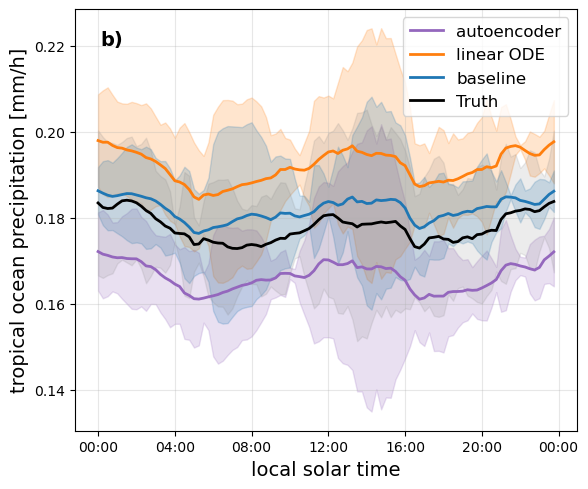

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# --- 1. Helper Functions ---
def compute_diurnal_cycle_with_ci(data, lon, steps_per_day=96, ci=0.95, model_name=None):
    n_points, n_timesteps = data.shape
    n_days = n_timesteps // steps_per_day
    data = data[:, :n_days * steps_per_day]
    data = data.reshape(n_points, n_days, steps_per_day)
    
    offset_steps = np.round(lon / 360.0 * steps_per_day).astype(int)
    shifted = np.empty_like(data)
    for i in range(n_points):
        shifted[i] = np.roll(data[i], -offset_steps[i], axis=-1)
        
    daily_cycles = shifted.mean(axis=0)
    mean_cycle = daily_cycles.mean(axis=0)
    std_cycle = daily_cycles.std(axis=0, ddof=1)
    print(f'{model_name} Phase= ', np.argmax(mean_cycle), ', Amplitude= ', np.max(mean_cycle))
    
    t_val = stats.t.ppf((1 + ci) / 2, df=n_days - 1)
    se = std_cycle / np.sqrt(n_days)
    return mean_cycle, mean_cycle - t_val * se, mean_cycle + t_val * se

def evaluate_diurnal(model_cycle, truth_cycle):
    rmse = np.sqrt(np.mean((model_cycle - truth_cycle) ** 2))
    bias = np.mean(model_cycle - truth_cycle)
    corr = np.corrcoef(model_cycle, truth_cycle)[0, 1]
    return {"RMSE": rmse, "Bias": bias, "Correlation": corr}

def run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=None):
    if model_names is None:
        model_names = [f"model_{i}" for i in range(len(model_data_list))]
        
    results = []
    for i, (model_data, truth_data, lon, model_name) in enumerate(zip(model_data_list, truth_data_list, lon_list, model_names)):
        model_cycle, model_lower, model_upper = compute_diurnal_cycle_with_ci(model_data, lon, model_name=model_name)
        truth_cycle, truth_lower, truth_upper = compute_diurnal_cycle_with_ci(truth_data, lon, model_name=model_name)
        
        metrics = evaluate_diurnal(model_cycle, truth_cycle)
        
        results.append({
            "model": model_names[i],
            "metrics": metrics,
            "model_cycle": model_cycle,
            "truth_cycle": truth_cycle,
            "lower": model_lower,
            "upper": model_upper,
            "truth_lower": truth_lower,
            "truth_upper": truth_upper,
        })
    return results

# --- 2. CONFIGURATION: Pick which models to show ---
models_to_plot = ['linear ODE', 'autoencoder', 'baseline'] 

# --- 3. DATA SETUP (Your exact variables) ---
tropics_max, tropics_min = 23.5, -23.5
# add_nonlin = True
line_width = 2
tropical_mask = (lat >= tropics_min) & (lat <= tropics_max)
mask = tropical_mask & ocean

model_data_list = [precip_org_pred[mask], precip_org_ED_pred[mask], precip_base_pred[mask], precip_org_nonlinED_pred[mask]]
truth_data_list = [precip_true[mask], precip_org_ED_True[mask], precip_true[mask], precip_org_nonlinED_True[mask]]
lon_list = [lon[mask], lon[mask], lon[mask], lon[mask]]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:brown']
labels = ['autoencoder', 'linear ODE', 'baseline', 'nonlinear ODE']

# if add_nonlin:
#     model_data_list.append(precip_org_nonlinED_pred[mask])
#     truth_data_list.append(precip_org_nonlinED_True[mask])
#     lon_list.append(lon[mask])
#     colors.append('tab:brown')
#     labels.append('nonlinear ODE')

roll = 12  # Because test set starts 03:00, but diurnal cycle should start at 00:00 local time
t = ds_time[-373 - roll: -373 - roll + 96]

# Run evaluation
results = run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=labels)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5))
FS = 14

# Plot selected models
for res, label, c in zip(results, labels, colors):
    if label not in models_to_plot:
        continue
        
    cycle_rolled = np.roll(res["model_cycle"], roll)
    lower_rolled = np.roll(res["lower"], roll)
    upper_rolled = np.roll(res["upper"], roll)
    
    ax.plot(t, cycle_rolled, color=c, linewidth=line_width, label=label)
    ax.fill_between(t, lower_rolled, upper_rolled, color=c, alpha=0.2)

# Plot Truth (always shown)
# Extract truth from the first result (truth_data_list[0] is the main truth)
truth_cycle = results[0]["truth_cycle"]
truth_lower = results[0]["truth_lower"]
truth_upper = results[0]["truth_upper"]

truth_cycle_rolled = np.roll(truth_cycle, roll)
truth_lower_rolled = np.roll(truth_lower, roll)
truth_upper_rolled = np.roll(truth_upper, roll)

ax.plot(t, truth_cycle_rolled, color='black', linewidth=line_width, label='Truth')
ax.fill_between(t, truth_lower_rolled, truth_upper_rolled, color='gray', alpha=0.15)
# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.text(0.05, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
ax.set_xlabel("local solar time", fontsize=FS)
ax.set_ylabel("tropical ocean precipitation [mm/h]", fontsize=FS)
ax.legend(loc='upper right', fontsize=FS-2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f'plots_paper/DYAMOND_diurnal_cycle_ocean_models={models_to_plot}.png', dpi=300, bbox_inches='tight')

autoencoder Phase=  59 , Amplitude=  0.20696722
autoencoder Phase=  62 , Amplitude=  0.21215491
linear ODE Phase=  61 , Amplitude=  0.21785377
linear ODE Phase=  63 , Amplitude=  0.21195376
baseline Phase=  36 , Amplitude=  0.2132696
baseline Phase=  62 , Amplitude=  0.21215491
nonlinear ODE Phase=  65 , Amplitude=  0.1949215
nonlinear ODE Phase=  63 , Amplitude=  0.21195376
2020-02-26T18:30:00.000000000


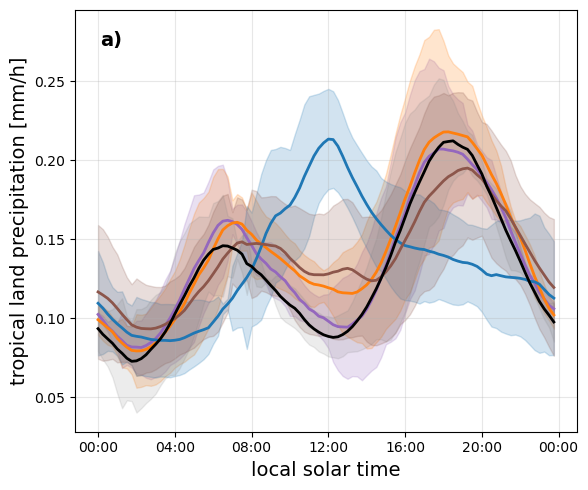

In [18]:
# --- 2. CONFIGURATION: Pick which models to show ---
models_to_plot = ['linear ODE', 'autoencoder', 'baseline', 'nonlinear ODE']  # <-- Edit this list!

# --- 3. DATA SETUP (Your exact variables) ---
tropics_max, tropics_min = 23.5, -23.5
# add_nonlin = True
line_width = 2
tropical_mask = (lat >= tropics_min) & (lat <= tropics_max)
mask = tropical_mask & land

model_data_list = [precip_org_pred[mask], precip_org_ED_pred[mask], precip_base_pred[mask], precip_org_nonlinED_pred[mask]]
truth_data_list = [precip_true[mask], precip_org_ED_True[mask], precip_true[mask], precip_org_nonlinED_True[mask]]
lon_list = [lon[mask], lon[mask], lon[mask], lon[mask]]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:brown']
labels = ['autoencoder', 'linear ODE', 'baseline', 'nonlinear ODE']

# if add_nonlin:
#     model_data_list.append(precip_org_nonlinED_pred[mask])
#     truth_data_list.append(precip_org_nonlinED_True[mask])
#     lon_list.append(lon[mask])
#     colors.append('tab:brown')
#     labels.append('nonlinear ODE')

roll = 12  # Because test set starts 03:00, but diurnal cycle should start at 00:00 local time
t = ds_time[-373 - roll: -373 - roll + 96]

# Run evaluation
results = run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=labels)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5))
FS = 14

# Plot selected models
for res, label, c in zip(results, labels, colors):
    if label not in models_to_plot:
        continue
        
    cycle_rolled = np.roll(res["model_cycle"], roll)
    lower_rolled = np.roll(res["lower"], roll)
    upper_rolled = np.roll(res["upper"], roll)
    
    ax.plot(t, cycle_rolled, color=c, linewidth=line_width, label=label)
    ax.fill_between(t, lower_rolled, upper_rolled, color=c, alpha=0.2)

# Plot Truth (always shown)
# Extract truth from the first result (truth_data_list[0] is the main truth)
truth_cycle = results[0]["truth_cycle"]
truth_lower = results[0]["truth_lower"]
truth_upper = results[0]["truth_upper"]

truth_cycle_rolled = np.roll(truth_cycle, roll)
truth_lower_rolled = np.roll(truth_lower, roll)
truth_upper_rolled = np.roll(truth_upper, roll)

ax.plot(t, truth_cycle_rolled, color='black', linewidth=line_width, label='Truth')
ax.fill_between(t, truth_lower_rolled, truth_upper_rolled, color='gray', alpha=0.15)
print(t[roll + 62])
# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.text(0.05, 0.95, 'a)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
ax.set_xlabel("local solar time", fontsize=FS)
ax.set_ylabel("tropical land precipitation [mm/h]", fontsize=FS)
# ax.legend(loc='upper right', fontsize=FS-2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(f'plots_paper/DYAMOND_diurnal_cycle_land_models={models_to_plot}.png', dpi=300, bbox_inches='tight')

In [106]:
print('AE ', t[(roll + 59) % 96])
print('ODE ',t[(roll + 61) % 96])
print('base ',t[(roll + 36) % 96])
print('ture ',t[(roll + 65) % 96])
print('nonlin ODE ',t[(roll + 62) % 96])

AE  2020-02-26T17:45:00.000000000
ODE  2020-02-26T18:15:00.000000000
base  2020-02-26T12:00:00.000000000
ture  2020-02-26T19:15:00.000000000
nonlin ODE  2020-02-26T18:30:00.000000000


### Precip autocorrelation

In [ ]:
def plain_autocorrelation(data, max_lag=None):
    """
    Fully vectorized plain autocorrelation using numpy.
    """
    n_coords, n_time = data.shape
    if max_lag is None:
        max_lag = n_time - 1
        
    # Center data per coordinate
    x_centered = data - np.nanmean(data, axis=1, keepdims=True)
    
    # FIX: Add axis=1 to specify we are windowing the time dimension
    x_win = np.lib.stride_tricks.sliding_window_view(x_centered, max_lag + 1, axis=1)
    
    # Compute covariance for all lags simultaneously
    cov = np.mean(x_centered[:, :n_time - max_lag, None] * x_win, axis=1)
    
    # Normalize by variance (lag-0)
    var = np.var(data, axis=1, keepdims=True)
    acorr = cov / var
    
    return acorr, np.nanmean(acorr, axis=0)

max_lag = 200
mask = tropical_mask #& land
_, ae_mean_acorr = plain_autocorrelation(precip_org_pred[mask], max_lag=max_lag)
_, led_mean_acorr = plain_autocorrelation(precip_org_ED_pred[mask], max_lag=max_lag)
_, nled_mean_acorr = plain_autocorrelation(precip_org_nonlinED_pred[mask], max_lag=max_lag)
_, base_mean_acorr = plain_autocorrelation(precip_base_pred[mask], max_lag=max_lag)
_, true_mean_acorr = plain_autocorrelation(precip_true[mask], max_lag=max_lag)

/tmp/ipykernel_203717/1385351310.py:24: RuntimeWarning: invalid value encountered in divide
  acorr = cov / var


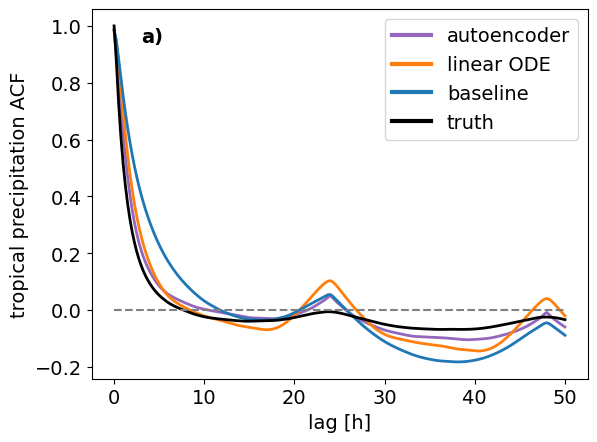

In [119]:
t = (np.arange(max_lag + 1) * 15 / 60)  # time in hours for 15-min steps
line_width = 2
add_nonlin = False
acovs = [ae_mean_acorr, led_mean_acorr, base_mean_acorr, true_mean_acorr]
# ci_lows = [ae_ci_low, led_ci_low, base_ci_low, true_ci_low]
# ci_highs = [ae_ci_high, led_ci_high, base_ci_high, true_ci_high]
labels = ['autoencoder', 'linear ODE', 'baseline', 'truth']
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'black']
if add_nonlin:
    acovs.insert(2, nled_mean_acorr)
    # ci_lows.insert(2, nled_ci_low)
    # ci_highs.insert(2, nled_ci_high)
    labels.insert(2, 'nonlinear ODE')
    colors.insert(2, 'tab:brown')

for acov, label, color in zip(acovs, labels, colors):
    plt.plot(t, acov, label=label, color=color, linewidth=line_width)
    # plt.fill_between(t, ci_low, ci_high, color=color, alpha=0.3)  # error bands are very small due to large sample size, can be omitted for clarity

FS = 14
plt.hlines(0, t[0], t[-1], colors='gray', linestyles='dashed')
plt.xlabel("lag [h]", fontsize=FS)
plt.ylabel("tropical precipitation ACF", fontsize=FS)
plt.tick_params(axis='both', labelsize=FS)
ax = plt.gca()
ax.text(0.1, 0.95, 'a)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
#plt.xlim(0, 24)
leg = plt.legend(fontsize=FS)
for line in leg.legend_handles:
    line.set_linewidth(3)
#plt.savefig(f'plots_paper/DYAMOND_autocorrelation_nonlin={add_nonlin}_long.png', dpi=300, bbox_inches='tight')

### Hyperparameter optimization

In [4]:
import os
tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min = [], [], [], [], [], [], [], []
for file in os.listdir('hyper_opt_precip/'):
    model = torch.load(f'hyper_opt_precip/{file}', weights_only=False, map_location=device)
    print(model.weight_decay, model.latent_dims, file, model.nonlinear_predictability)
    tps.append(model.past_timesteps)
    ws.append(model.weight_decay)
    dzs.append(model.latent_dims)
    R2s_precip.append(max(model.R2).item())
    R2s_predict_upper.append(torch.mean(model.nonlinear_predictability).item())
    R2s_predict_upper_min.append(torch.min(model.nonlinear_predictability).item())
    R2s_predict_lower.append(np.mean(model.linear_predictability))
    R2s_predict_lower_min.append(np.min(model.linear_predictability))

1e-05 6 20260527143050_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.6872, 0.8944, 0.9181, 0.9479, 0.6955, 0.7848])
0.0 8 20260528010951_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.3392, 0.2984, 0.4345, 0.8653, 0.8918, 0.7588, 0.4071, 0.4197])
0.0 6 20260527145152_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.8479, 0.4993, 0.5921, 0.4666, 0.6020, 0.6949])
1e-05 2 20260527001603_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.5050, 0.6666])
1e-06 2 20260526192321_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-06_eps=1.0.pkl tensor([0.3621, 0.4964])
0.0 2 20260526194107_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.7096, 0.4157])
1e-05 4 20260526234615_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.8529, 0.9258, 0.7811, 0.8310])
0.0001 4 

In [5]:
df_DYAMOND = pd.DataFrame([tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min],
             index=['past_timesteps', 'weight_decay', 'latent_dims', 'R2_precip', 'R2_predict_upper', 'R2_predict_upper_min', 'R2_predict_lower', 'R2_predict_lower_min']).T.sort_values('R2_precip', ascending=False)
df_DYAMOND['marker'] = df_DYAMOND.latent_dims.map({2.0: 'o', 4.0: 's', 6.0: '^', 8.0: 'P'})

In [6]:
df_DYAMOND

,past_timesteps,weight_decay,latent_dims,R2_precip,R2_predict_upper,R2_predict_upper_min,R2_predict_lower,R2_predict_lower_min,marker
2,20.0,0.000000,6.0,0.691366,0.617137,0.466613,0.395511,0.236101,^
14,20.0,0.000000,4.0,0.690712,0.821373,0.743180,0.499645,0.288245,s
1,20.0,0.000000,8.0,0.688899,0.551844,0.298418,0.365825,0.047950,P
15,20.0,0.000001,4.0,0.685771,0.826106,0.665702,0.488011,0.356107,s
16,20.0,0.000001,6.0,0.685580,0.732914,0.358778,0.559490,0.174333,^
17,20.0,0.000001,8.0,0.684468,0.699831,0.406824,0.459623,0.177513,P
4,20.0,0.000001,2.0,0.671559,0.429288,0.362133,0.023693,0.013154,o
13,20.0,0.000010,8.0,0.670356,0.749085,0.417310,0.581774,0.179974,P
0,20.0,0.000010,6.0,0.669682,0.821318,0.687151,0.593198,0.238760,^
6,20.0,0.000010,4.0,0.668788,0.847714,0.781124,0.501018,0.341124,s


In [7]:
import os
tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min = [], [], [], [], [], [], [], []
for file in os.listdir('/work/bd1179/b309297/L96/hyper_opt/all_dims_offline_R2/'):
    model = torch.load(f'/work/bd1179/b309297/L96/hyper_opt/all_dims_offline_R2/{file}', weights_only=False, map_location=device)
    tps.append(model.past_timesteps)
    ws.append(model.weight_decay)
    dzs.append(model.latent_dims)
    R2s_precip.append(model.R2[-1])
    R2s_predict_upper.append(np.mean(model.nonlinear_predictability))
    R2s_predict_upper_min.append(np.min(model.nonlinear_predictability))
    R2s_predict_lower.append(np.mean(model.linear_predictability))
    R2s_predict_lower_min.append(np.min(model.linear_predictability))

df_L96 = pd.DataFrame([tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min],
             index=['past_timesteps', 'weight_decay', 'latent_dims', 'R2_precip', 'R2_predict_upper', 'R2_predict_upper_min', 'R2_predict_lower', 'R2_predict_lower_min']).T.sort_values('R2_precip', ascending=False)
df_L96['marker'] = df_L96.latent_dims.map({2.0: 'o', 4.0: 's', 6.0: '^', 8.0: 'P'})
df_L96

,past_timesteps,weight_decay,latent_dims,R2_precip,R2_predict_upper,R2_predict_upper_min,R2_predict_lower,R2_predict_lower_min,marker
15,1000.0,0.000100,8.0,0.937867,0.894698,0.803321,0.815861,0.604839,P
11,1000.0,0.000001,8.0,0.937799,0.861163,0.739908,0.880710,0.794494,P
5,1000.0,0.000100,6.0,0.937052,0.931577,0.885437,0.841895,0.731802,^
3,1000.0,0.000000,6.0,0.936999,0.913012,0.772976,0.853247,0.633954,^
7,1000.0,0.000010,8.0,0.936929,0.927761,0.852215,0.846309,0.610077,P
17,1000.0,0.000010,6.0,0.936124,0.879178,0.784091,0.735785,0.577973,^
14,1000.0,0.000001,6.0,0.934642,0.936299,0.903825,0.861961,0.794038,^
2,1000.0,0.000000,8.0,0.933921,0.928471,0.834617,0.874504,0.725698,P
16,1000.0,0.001000,6.0,0.932172,0.928186,0.828202,0.834477,0.672208,^
9,1000.0,0.000100,4.0,0.931875,0.421492,0.292654,0.320723,0.175380,s


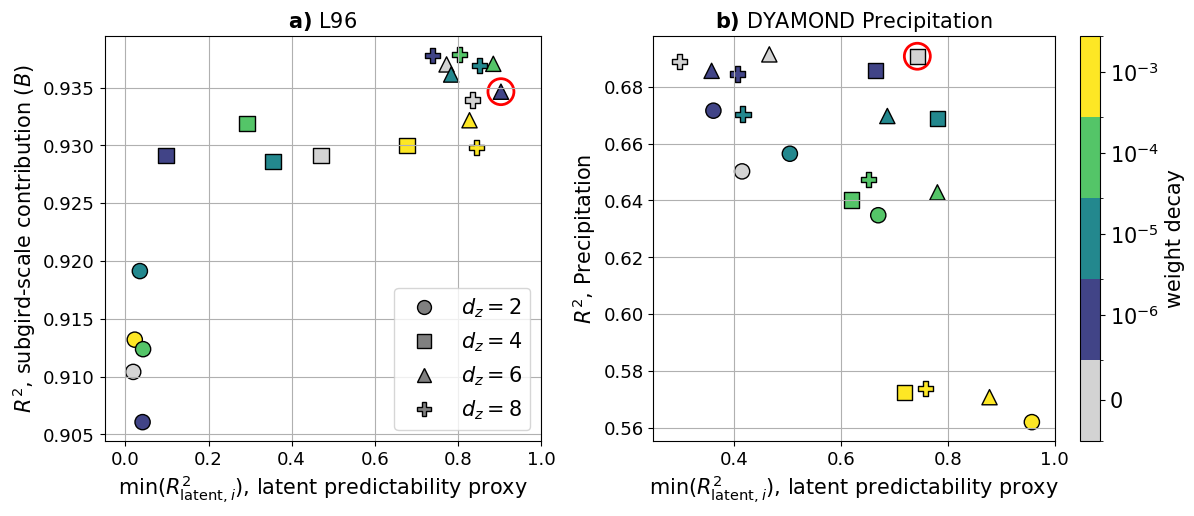

In [9]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
FS = 15
def hyper_opt_figure(df, target, cbar=True, legend=True, fig=None, ax=None):
    markers={2.0:'o', 4.0:'s', 6.0:'^', 8.0:'P'}
    cmap=colors.ListedColormap(['lightgray',*plt.cm.viridis(np.linspace(.2,1,4))])
    bounds=[0, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3]
    norm=colors.BoundaryNorm(bounds,cmap.N)

    if not fig:
        fig,ax=plt.subplots(figsize=(6,5))

    for ld,m in markers.items():
        s=df[df.latent_dims==ld]
        # ax.scatter(s.R2_predict_upper,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
        ax.scatter(s.R2_predict_upper_min,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
                marker=m,edgecolor='black',linewidth=1, s=120)

    # highlight target model
    t=df[(df.latent_dims==target['latent_dims'])&
        (df.weight_decay==target['weight_decay'])&
        (df.past_timesteps==target['past_timesteps'])].iloc[0]

    # x,y=t.R2_predict_upper,t.R2_precip
    x,y=t.R2_predict_upper_min,t.R2_precip
    ax.scatter(x,y,s=350,facecolors='none',edgecolors='red',linewidths=2,zorder=0)

    if cbar:
        cb=plt.colorbar(ScalarMappable(norm=norm,cmap=cmap),ax=ax)
        cb.set_ticks([2.5e-7, 3e-6, 3e-5, 3e-4, 3e-3])
        cb.set_ticklabels(['0',r'$10^{-6}$',r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'], fontsize=FS)
        cb.set_label('weight decay', fontsize=FS)
    if legend:
        ax.legend(handles=[
            Line2D([0],[0],marker=m,linestyle='None',color='none',
                markerfacecolor='gray',markeredgecolor='black', markersize=10,
                label=rf'$d_z={{{int(ld)}}}$')
            for ld,m in markers.items()
        ],loc='lower right',frameon=True, fontsize=FS)

    ax.set_xlabel(r'$\min(R^2_{\text{latent},i})$, latent predictability proxy', fontsize=FS)
    # ax.set_xlabel(r'$\bar R^2$, upper predictability bound', fontsize=FS)
    ax.set_ylabel(r'$R^2$, Precipitation', fontsize=FS)
    ax.grid()
    ax.set_xlim(-.05, 1.0)
    ax.tick_params(axis='both', which='major', labelsize=FS-2)
    plt.tight_layout()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.15]})
hyper_opt_figure(df_DYAMOND, dict(latent_dims=4.0,weight_decay=0.0,past_timesteps=20.0), True, False, fig, ax1)
hyper_opt_figure(df_L96, dict(latent_dims=6.0,weight_decay=1.e-6,past_timesteps=1000.0), False, True, fig, ax2)
ax1.set(xlim=(.25, 1.0))
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation', fontsize=FS)
ax2.set_title(r'$\mathbf{a)}$ L96', fontsize=FS)
ax2.set_ylabel(r'$R^2$, subgird-scale contribution ($B$)', fontsize=FS)
plt.savefig('plots_paper/hyper_opt.png', dpi=300, bbox_inches='tight')

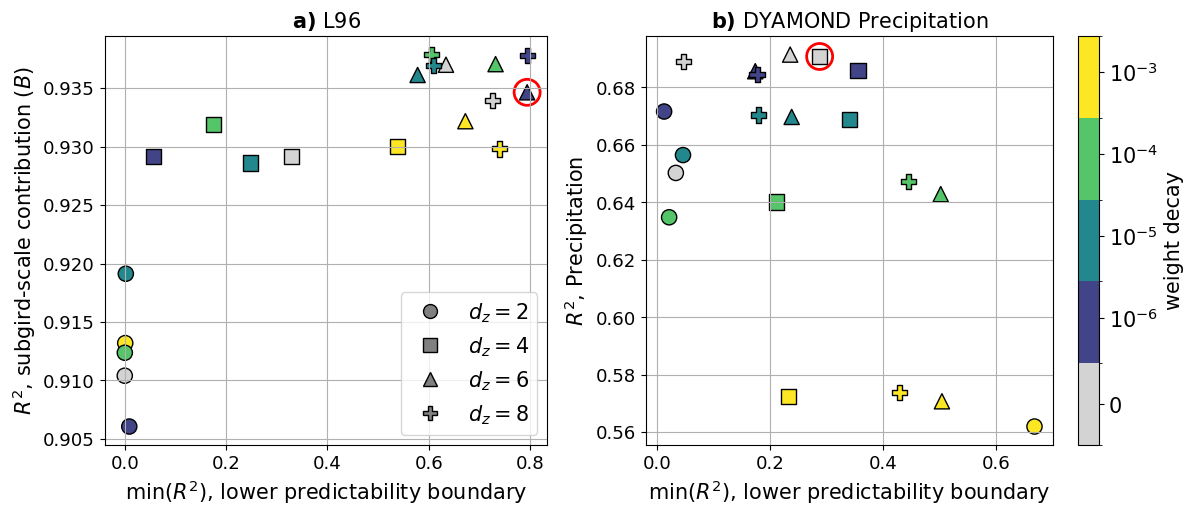

In [10]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
FS = 15
def hyper_opt_figure(df, target, cbar=True, legend=True, fig=None, ax=None):
    markers={2.0:'o', 4.0:'s', 6.0:'^', 8.0:'P'}
    cmap=colors.ListedColormap(['lightgray',*plt.cm.viridis(np.linspace(.2,1,4))])
    bounds=[0, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3]
    norm=colors.BoundaryNorm(bounds,cmap.N)

    if not fig:
        fig,ax=plt.subplots(figsize=(6,5))

    for ld,m in markers.items():
        s=df[df.latent_dims==ld]
        ax.scatter(s.R2_predict_lower_min,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
                marker=m,edgecolor='black',linewidth=1, s=120)

    # highlight target model
    t=df[(df.latent_dims==target['latent_dims'])&
        (df.weight_decay==target['weight_decay'])&
        (df.past_timesteps==target['past_timesteps'])].iloc[0]

    x,y=t.R2_predict_lower_min,t.R2_precip
    ax.scatter(x,y,s=350,facecolors='none',edgecolors='red',linewidths=2,zorder=0)

    if cbar:
        cb=plt.colorbar(ScalarMappable(norm=norm,cmap=cmap),ax=ax)
        cb.set_ticks([2.5e-7, 3e-6, 3e-5, 3e-4, 3e-3])
        cb.set_ticklabels(['0',r'$10^{-6}$',r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'], fontsize=FS)
        cb.set_label('weight decay', fontsize=FS)
    if legend:
        ax.legend(handles=[
            Line2D([0],[0],marker=m,linestyle='None',color='none',
                markerfacecolor='gray',markeredgecolor='black', markersize=10,
                label=rf'$d_z={{{int(ld)}}}$')
            for ld,m in markers.items()
        ],loc='lower right',frameon=True, fontsize=FS)

    ax.set_xlabel(r'$\min(R^2)$, lower predictability boundary', fontsize=FS)
    ax.set_ylabel(r'$R^2$, Precipitation', fontsize=FS)
    ax.grid()
    #ax.set_xlim(0, 1.0)
    ax.tick_params(axis='both', which='major', labelsize=FS-2)
    plt.tight_layout()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.15]})
hyper_opt_figure(df_DYAMOND, dict(latent_dims=4.0,weight_decay=0.0,past_timesteps=20.0), True, False, fig, ax1)
hyper_opt_figure(df_L96, dict(latent_dims=6.0,weight_decay=1.e-6,past_timesteps=1000.0), False, True, fig, ax2)
#ax1.set(xlim=(.25, 1.0))
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation', fontsize=FS)
ax2.set_title(r'$\mathbf{a)}$ L96', fontsize=FS)
ax2.set_ylabel(r'$R^2$, subgird-scale contribution ($B$)', fontsize=FS)
plt.savefig('plots_paper/hyper_opt_lower.png', dpi=300, bbox_inches='tight')

### Initial past timesteps hyper parameter optimization

In [1]:
import pandas as pd
import os

In [3]:
pts, dzs, losses, preds = [], [], [], []
for file in os.listdir('initial_pt_hyper_opt/'):
    if 'pkl' in file:
        model = torch.load('initial_pt_hyper_opt/' + file, map_location='cpu', weights_only=False)
        pts.append(model.past_timesteps)
        dzs.append(model.latent_dims)
        losses.append(max(model.R2))
        preds.append(np.mean(model.nonlinear_predictability.detach().cpu().numpy()))

df = pd.DataFrame(np.array([pts, dzs, losses]).T, columns=['M', 'd_z', 'test loss'])
df = df.sort_values(['d_z', 'M'])
# Format the columns as requested
df['M'] = df['M'].astype(int)           # M as integer
df['d_z'] = df['d_z'].astype(int)       # d_z as integer
df['test loss'] = df['test loss'].map('{:.3f}'.format)  # 3 decimal places
#df['upper predictability boundary R^2'] = df['upper predictability boundary R^2'].map('{:.2f}'.format)  # 2 decimal places

df.to_latex('initial_pt_hyper_opt/summary_latex_table', index=False)
df

,M,d_z,test loss
5,3,4,0.644
1,5,4,0.674
3,10,4,0.686
4,20,4,0.691
0,3,8,0.648
2,5,8,0.674
7,10,8,0.690
6,20,8,0.689


### Eval reconstruction loss

In [7]:
from training_gpu import get_standardized_ds

In [8]:
ds = get_standardized_ds('global', 'ocean_land', rescale_precip=False)
ds

(8, 3897, 81920)


tensor([[[-1.4116e+00, -1.3922e+00, -1.4148e+00,  ..., -5.7732e-01,
          -3.6179e-01, -6.0086e-01],
         [-1.4151e+00, -1.3975e+00, -1.4160e+00,  ..., -5.6003e-01,
          -3.4510e-01, -5.8291e-01],
         [-1.4162e+00, -1.4003e+00, -1.4151e+00,  ..., -5.4212e-01,
          -3.2678e-01, -5.6638e-01],
         ...,
         [-1.4376e+00, -1.4519e+00, -1.4309e+00,  ..., -1.4257e-01,
          -1.5682e-01, -2.2748e-01],
         [-1.4377e+00, -1.4524e+00, -1.4310e+00,  ..., -1.4139e-01,
          -1.5665e-01, -2.1805e-01],
         [-1.4375e+00, -1.4526e+00, -1.4310e+00,  ..., -1.4054e-01,
          -1.5669e-01, -2.0873e-01]],

        [[-1.2066e+00, -1.2116e+00, -1.1960e+00,  ...,  5.3772e-01,
           6.3394e-01,  5.1326e-01],
         [-1.2059e+00, -1.2108e+00, -1.1953e+00,  ...,  5.5646e-01,
           6.3927e-01,  5.3358e-01],
         [-1.2041e+00, -1.2089e+00, -1.1936e+00,  ...,  6.0786e-01,
           6.4486e-01,  5.4986e-01],
         ...,
         [-1.2322e+00, -1

In [33]:
#model_decoder = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251103181446_global_oceanland_threshold=0.0_kernel=3_alpha=0.7.pkl', weights_only=False)
#model_decoder = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104132641_global_oceanland_threshold=0.0_kernel=3_alpha=1.0.pkl', weights_only=False)
model_decoder = torch.load('networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2]_latent_dims=3_past_timesteps=20/20260114181941_global_ocean_land_rp=False_alpha=75.0_lr=0.001_weigth_decay=0.0_eps=1.0.pkl', weights_only=False, map_location=device)
model_decoder.X = ds 
model_decoder.X = model_decoder.X.to(device)

In [34]:
_, valloader, _ = get_dataloader(ds, share_val=.1, batch_size=1)

Nsamples = 5
Ncoords = valloader.dataset.__len__()
coords = np.random.randint(0, Ncoords, size=Nsamples)
coords

array([ 5909, 25206, 46637, 18250, 35757])

In [35]:
def reconstruct_input(model, valloader, Nsamples=1):
    # Predict precip on val set and collect targets
    model.eval()
    X_past, X_past_rec = [], []
    with torch.no_grad():
        Ncoords = valloader.dataset.__len__()
        coords = np.random.randint(0, Ncoords, size=Nsamples)
        # Preprocessing
        x_present, x_past, _ = preprocess(model.X, coords, model.past_timesteps, model.n_features, 
                                          valloader.dataset.tstart, valloader.dataset.tend, 
                                          model.memory_indices)

        # Reconstruct
        x_past_rec = model.forward(x_past, x_present)[1].detach().cpu()

        X_past_rec.append(x_past_rec)
        X_past.append(x_past.detach().cpu())
    X_past = torch.cat(X_past, dim=0).detach().cpu().numpy()
    X_past_rec = torch.cat(X_past_rec, dim=0).detach().cpu().numpy()
    return X_past, X_past_rec

def R2_reconstruction(model, valloader):
    X_past, X_past_rec = reconstruct_input(model, valloader, Nsamples=1000)
    for var in range(3):
        x, y = X_past[:, var, :].flatten(), X_past_rec[:, var, :].flatten()
        r2 = R2Score()
        x, y = torch.tensor(x), torch.tensor(y)
        print(torch.nn.MSELoss()(x, y))
        r2_score = r2(x, y)
        print(f'Variable {var}: R2 = {r2_score.item()}')

R2_reconstruction(model_decoder, valloader)

tensor(0.0012)
Variable 0: R2 = 0.9987523555755615
tensor(0.0013)
Variable 1: R2 = 0.9986123442649841
tensor(0.0013)
Variable 2: R2 = 0.9985873699188232


Text(0, 0.5, 'Feature 0')

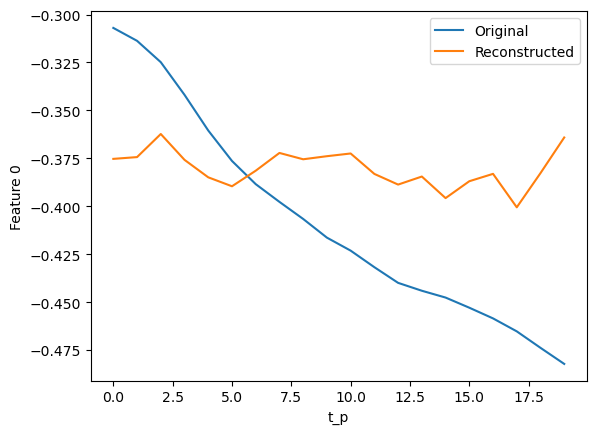

In [76]:
X_past, X_past_rec = reconstruct_input(model_decoder, valloader)
var = 0
plt.plot(X_past[150, var, :], label='Original')
plt.plot(X_past_rec[150, var, :], label='Reconstructed')
plt.legend()
#plt.ylim(-2, 2)
plt.xlabel('t_p')
plt.ylabel(f'Feature {var}')

In [148]:
X_past.shape

(370, 7, 20)

Text(0, 0.5, 'Feature 0 at t_p=19')

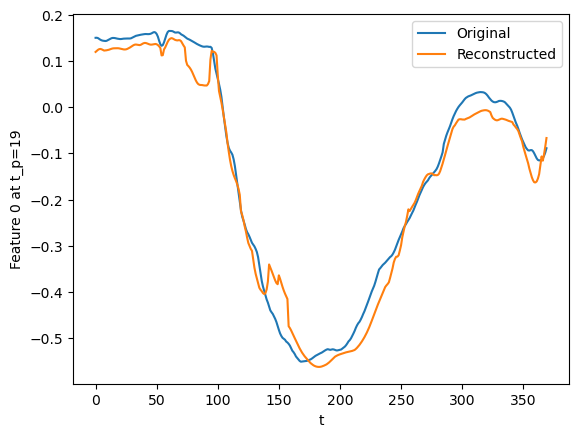

In [77]:
var = 0
pt = 19
plt.plot(X_past[:, var, pt], label='Original')
plt.plot(X_past_rec[:, var, pt], label='Reconstructed')
plt.legend()
plt.xlabel('t')
plt.ylabel(f'Feature {var} at t_p={pt}')

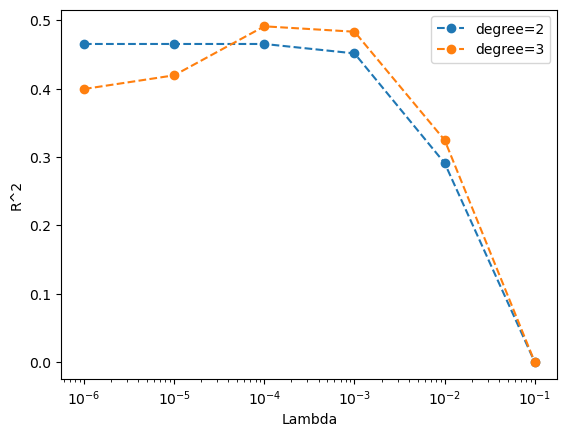

In [5]:
lambdas_scores = np.load('SINDy_ODEs/degree=2/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
lambdas_scores
plt.plot(lambdas_scores[:, 0], lambdas_scores[:, 1], marker='o', linestyle='--', label='degree=2')

lambdas_scores = np.load('SINDy_ODEs/degree=3/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
lambdas_scores
plt.plot(lambdas_scores[:, 0], lambdas_scores[:, 1], marker='o', linestyle='--', label='degree=3')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('R^2')
plt.legend()

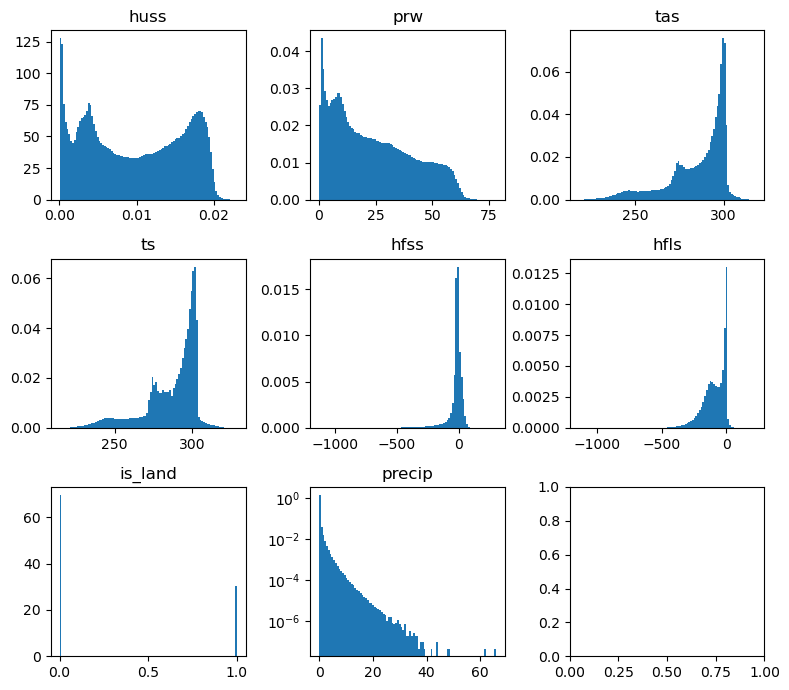

In [3]:
fig, axs = plt.subplots(3, 3, figsize=(8, 7))
axs = axs.flatten()
for i, var in enumerate(['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']):
    axs[i].hist(ds[i,:, ::10].flatten(), bins=100, density=True)
    scale = 'log' if var=='precip' else 'linear'
    axs[i].set(title=var, yscale=scale)

plt.tight_layout()

In [8]:
P_scaled = np.log(1 + ds[-1])

In [11]:
P_rescaled = np.exp(P_scaled) - 1

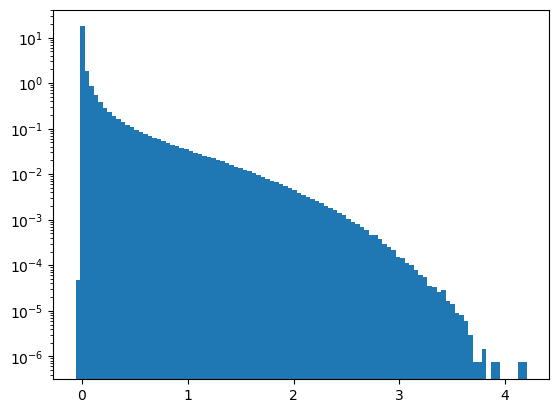

In [10]:
plt.hist(P_scaled.flatten()[::10], bins=100, density=True)
plt.yscale('log')

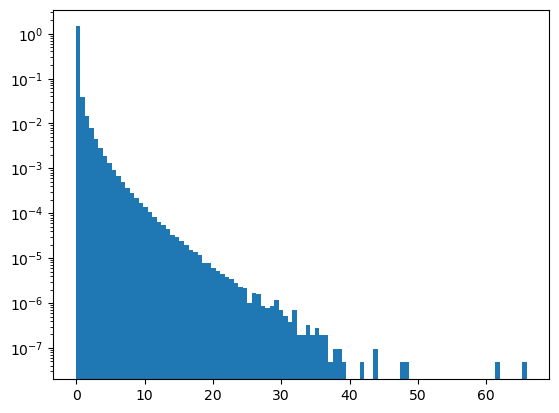

In [12]:
plt.hist(P_rescaled.flatten()[::10], bins=100, density=True)
plt.yscale('log')

In [2]:
ds_standardized = get_standardized_ds()

(8, 3897, 81920)


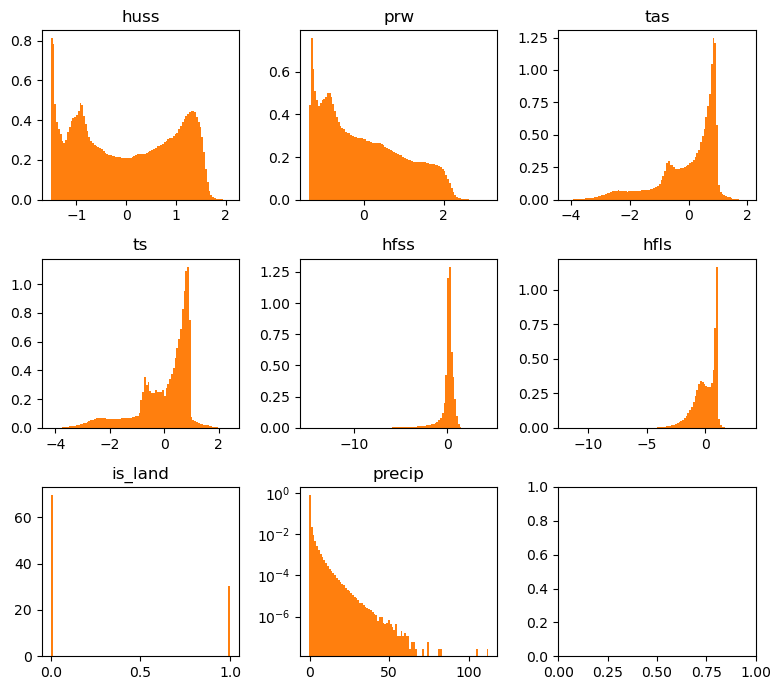

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(8, 7))
axs = axs.flatten()
for i, var in enumerate(['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']):
    axs[i].hist(ds_standardized[i,:, ::10].flatten(), bins=100, density=True, color='tab:orange')
    scale = 'log' if var=='precip' else 'linear'
    axs[i].set(title=var, yscale=scale)

plt.tight_layout()

### Accuracy with respect to number of past timesteps

In [2]:
model_base = torch.load('networks/NNbase/n_features=6_memory_indices=None_latent_dims=0_past_timesteps=0/20251107135137_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_3 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=3/20251107200823_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_10 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251107204236_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_20 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=20/20251108002837_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)

In [4]:
model_base.R2

[0.528276801109314]

In [6]:
print(r'$\ell$')

$\ell$


0.36440160349319056
0.32479930202982105
0.3052922608771157


[Text(0.5, 0, 'epoch'),
 Text(0, 0.5, '$\\ell = 0.7 \\ell_{Precip} + 0.3 \\ell_{recon}$')]

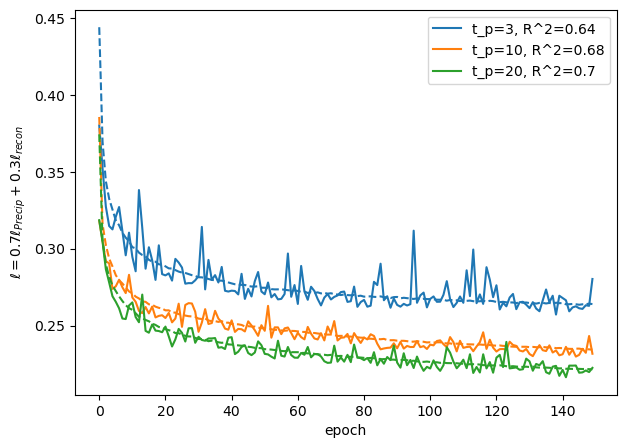

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for model, c in zip([model_3, model_10, model_20], ['tab:blue', 'tab:orange', 'tab:green']):
    plot_loss(model, label=f't_p={model.past_timesteps}, R^2={round(model.R2[0], 2)}', ax=ax, color=c)
ax.legend()
ax.set(xlabel='epoch', ylabel=r'$\ell = 0.7 \ell_{Precip} + 0.3 \ell_{recon}$')